In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ROOT = "./"
train = pd.read_csv(DATASET_ROOT + "IMT2024011_train_var2.csv")
test = pd.read_csv(DATASET_ROOT + "IMT2024011_test_var2.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)
print(train.head())
print("missing values:", train.isna().sum().sum(), test.isna().sum().sum())
print(train.describe().T[["min", "max", "mean", "std"]])

train shape: (1000, 4)
test shape : (1000, 3)
         x1        x2        x3         y
0 -1.000000  0.246924  0.309148 -4.799358
1 -0.412404  0.847874  0.470653  1.880698
2  0.018629  0.003496  0.033549  0.811511
3 -0.162361  0.715610 -0.331987  0.445240
4 -0.123493 -0.145421 -0.663828  0.580287
missing values: 0 0
          min        max      mean       std
x1  -1.000000   1.000000  0.009836  0.673968
x2  -1.000000   1.000000 -0.041420  0.680354
x3  -1.000000   1.000000 -0.002203  0.697416
y  -29.511181  39.328185  2.239359  7.035273


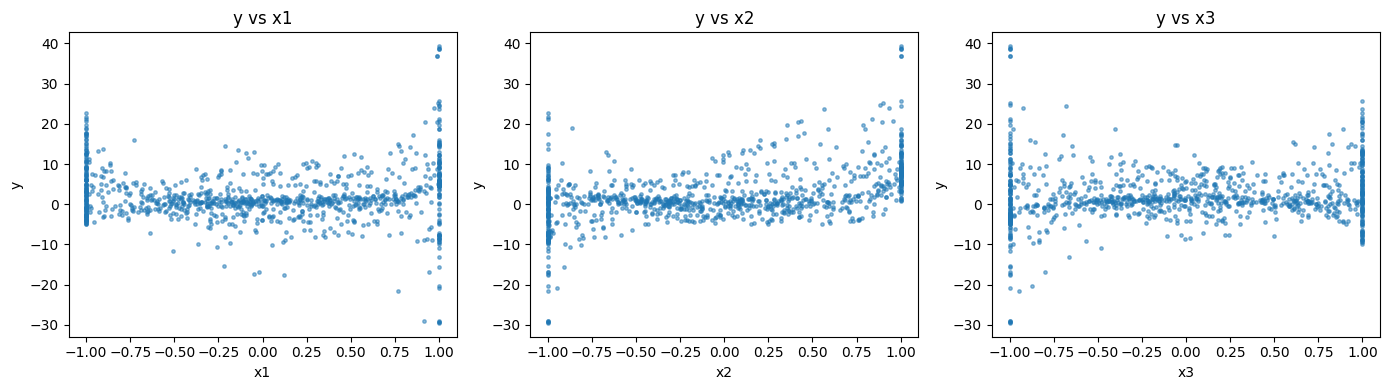

In [2]:
features = ["x1", "x2", "x3"]

# --- y vs each variable ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, f in zip(axes.ravel(), features):
    ax.scatter(train[f], train["y"], s=6, alpha=0.5)
    ax.set_xlabel(f)
    ax.set_ylabel("y")
    ax.set_title(f"y vs {f}")
plt.tight_layout()
plt.show()

      x1    x2    x3     y
x1  1.00  0.01 -0.02  0.02
x2  0.01  1.00 -0.07  0.47
x3 -0.02 -0.07  1.00  0.10
y   0.02  0.47  0.10  1.00


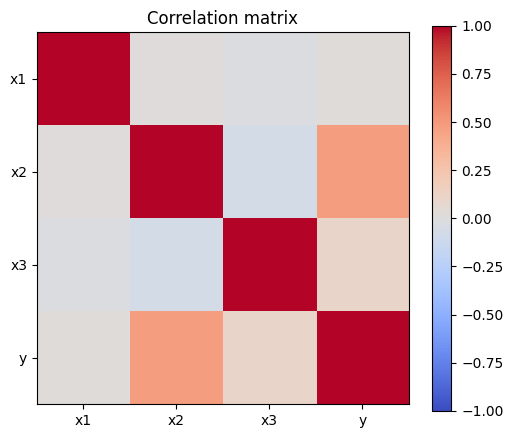

x2       0.470
x1*x2    0.428
x1^2     0.269
x2*x3   -0.164
x3       0.103
x2^2     0.102
x3^2     0.046
x1*x3    0.020
x1       0.019
dtype: float64


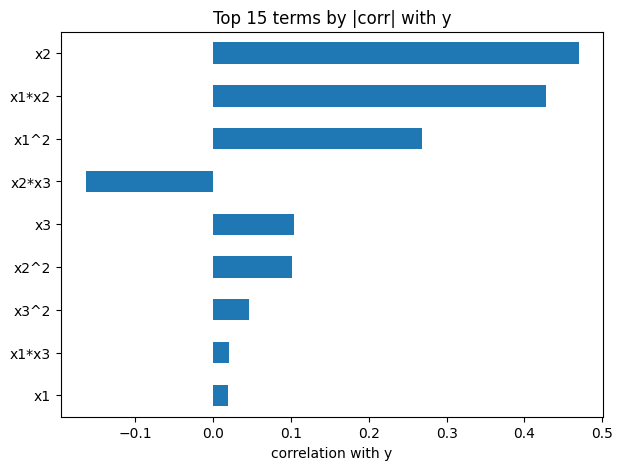

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import combinations

# (a) plain correlation matrix incl. y
corr = train[features + ["y"]].corr()
print(corr.round(2))

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(4), corr.columns); plt.yticks(range(4), corr.columns)
plt.title("Correlation matrix"); plt.show()

# (b) correlation of y with engineered terms: x_i, x_i^2, x_i*x_j
terms = {}
for f in features:
    terms[f] = train[f]
    terms[f + "^2"] = train[f] ** 2
for a, b in combinations(features, 2):
    terms[a + "*" + b] = train[a] * train[b]

r = pd.Series({k: np.corrcoef(v, train["y"])[0, 1] for k, v in terms.items()})
top = r.reindex(r.abs().sort_values(ascending=False).index).head(15)
print(top.round(3))

top[::-1].plot.barh(figsize=(7, 5))
plt.xlabel("correlation with y"); plt.title("Top 15 terms by |corr| with y")
plt.show()

In [4]:
import os, itertools, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

# ---------- device & dtype ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# float32 is ~2x faster on GPU and accurate enough here; switch to float64 if needed
DTYPE = torch.float32 if DEVICE.type == "cuda" else torch.float64
torch.set_default_dtype(DTYPE)
print(f"device: {DEVICE} | dtype: {DTYPE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs("output_var2", exist_ok=True)

X_np, y_np, X_test_np = train[features].values, train["y"].values, test[features].values
X = torch.as_tensor(X_np, dtype=DTYPE, device=DEVICE)
y = torch.as_tensor(y_np, dtype=DTYPE, device=DEVICE)
X_test = torch.as_tensor(X_test_np, dtype=DTYPE, device=DEVICE)

# ---------- features ----------
BASIS = "monomial"                      # or "legendre"

def leg_vander(x, deg):                 # columns P_0(x)..P_deg(x) via the three-term recurrence
    P = [torch.ones_like(x), x]
    for k in range(1, deg):
        P.append(((2 * k + 1) * x * P[k] - k * P[k - 1]) / (k + 1))
    return torch.stack(P[:deg + 1], dim=1)

def poly_features(A, deg, basis=None):
    basis = basis or BASIS
    nv = A.shape[1]
    if basis == "monomial":
        cols = [A[:, list(c)].prod(dim=1) for d in range(1, deg + 1)
                for c in itertools.combinations_with_replacement(range(nv), d)]
    else:
        V = [leg_vander(A[:, i], deg) for i in range(nv)]
        cols = [torch.stack([V[i][:, e[i]] for i in range(nv)]).prod(dim=0)
                for e in itertools.product(range(deg + 1), repeat=nv) if 0 < sum(e) <= deg]
    return torch.stack(cols, dim=1)

print("degree-20 feature matrix:", poly_features(X, 20).shape)   # expect (1000, 1770)

# ---------- elastic net: argmin ||y - Xb||^2 + lam2*||b||^2 + lam1*||b||_1  (bias not penalized) ----------
def soft(v, t):
    return torch.sign(v) * torch.clamp(v.abs() - t, min=0)

def rmse(A, t, w, b):
    return torch.sqrt(((A @ w + b - t) ** 2).mean())

def fit_enet(Xt, yt, lam1, lam2, sigma, iters, Xv=None, yv=None, log_every=1):
    """FISTA proximal gradient with *analytical* gradients (GPU-friendly, no autograd graph)."""
    # L = 2 * (||[X 1]||_2^2 + lam2)  — Lipschitz constant of the smooth part
    L = 2 * (sigma ** 2 + lam2)
    p = Xt.shape[1]
    w = torch.zeros(p, dtype=Xt.dtype, device=Xt.device)
    b = torch.zeros((), dtype=Xt.dtype, device=Xt.device)
    zw, zb, t = w.clone(), b.clone(), 1.0
    tr_curve, va_curve = [], []
    n_log = max(iters // log_every, 1)
    # pre-allocate curve buffers on GPU then move once
    tr_buf = torch.empty(n_log, dtype=Xt.dtype, device=Xt.device)
    va_buf = torch.empty(n_log, dtype=Xt.dtype, device=Xt.device) if Xv is not None else None
    log_i = 0
    XtT = Xt.T.contiguous()   # (p, n) — reused every iter
    for i in range(iters):
        # residual r = X zw + zb - y
        r = Xt @ zw + zb - yt
        # analytical grads of ||r||^2 + lam2 ||zw||^2
        gw = 2 * (XtT @ r) + (2 * lam2) * zw
        gb = 2 * r.sum()
        # proximal + Nesterov momentum
        w_new = soft(zw - gw / L, lam1 / L)
        b_new = zb - gb / L
        t_new = (1 + (1 + 4 * t * t) ** 0.5) / 2
        mom = (t - 1) / t_new
        zw = w_new + mom * (w_new - w)
        zb = b_new + mom * (b_new - b)
        w, b, t = w_new, b_new, t_new
        if (i + 1) % log_every == 0:
            tr_buf[log_i] = rmse(Xt, yt, w, b)
            if Xv is not None:
                va_buf[log_i] = rmse(Xv, yv, w, b)
            log_i += 1
    if Xv is None:
        return w, b, tr_buf
    return w, b, tr_buf, va_buf


device: cuda | dtype: torch.float32
GPU: Tesla T4
degree-20 feature matrix: torch.Size([1000, 1770])


In [5]:
def run_degree(DEG, lam1_grid, lam2_grid, K=10, iters=800, final_iters=3000,
               log_every=1, seed=0, out_dir="output_var2", show=False):
    t0 = time.time()
    folder = os.path.join(out_dir, f"deg{DEG}"); os.makedirs(folder, exist_ok=True)
    Phi = poly_features(X, DEG)
    Phi_test = poly_features(X_test, DEG)
    Y = y
    n, p = Phi.shape
    # folds on CPU indices (randperm on GPU is fine too)
    folds = torch.randperm(n, generator=torch.Generator(device="cpu").manual_seed(seed)).chunk(K)
    n_log = iters // log_every
    curves = torch.zeros(len(lam1_grid), len(lam2_grid), K, 2, n_log, dtype=DTYPE, device=DEVICE)

    for k in range(K):
        va = folds[k].to(DEVICE)
        tr = torch.cat([folds[j] for j in range(K) if j != k]).to(DEVICE)
        Xt, yt, Xv, yv = Phi[tr], Y[tr], Phi[va], Y[va]
        # spectral norm of [X | 1] on GPU
        ones = torch.ones(len(tr), 1, dtype=DTYPE, device=DEVICE)
        sigma = torch.linalg.matrix_norm(torch.cat([Xt, ones], 1), 2)
        for i, l1 in enumerate(lam1_grid):
            for j, l2 in enumerate(lam2_grid):
                _, _, c_tr, c_va = fit_enet(Xt, yt, l1, l2, sigma, iters, Xv, yv, log_every)
                curves[i, j, k, 0], curves[i, j, k, 1] = c_tr, c_va
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        print(f"deg {DEG}: fold {k+1}/{K} done ({(time.time()-t0)/60:.1f} min)")

    final = curves[..., 1, -1]                          # val RMSE at last logged iter
    cv_rmse = final.mean(dim=2)
    bi, bj = divmod(int(cv_rmse.argmin().item()), len(lam2_grid))
    cv_se = (final[bi, bj].std() / (K ** 0.5)).item()

    # ---- plot 1: train/val curves (move to CPU for matplotlib) ----
    curves_cpu = curves.detach().cpu()
    cv_rmse_cpu = cv_rmse.detach().cpu()
    fig, axes = plt.subplots(len(lam1_grid), len(lam2_grid), figsize=(4 * len(lam2_grid), 3 * len(lam1_grid)),
                             sharex=True, sharey=True, squeeze=False)
    it = torch.arange(1, n_log + 1) * log_every
    for i in range(len(lam1_grid)):
        for j in range(len(lam2_grid)):
            ax = axes[i, j]
            for idx, (name, col) in enumerate([("train", "tab:blue"), ("val", "tab:orange")]):
                m = curves_cpu[i, j, :, idx].mean(0).numpy()
                s = curves_cpu[i, j, :, idx].std(0).numpy()
                ax.plot(it.numpy(), m, color=col, label=name)
                ax.fill_between(it.numpy(), m - s, m + s, color=col, alpha=0.2)
            ax.set_title(f"λ1={lam1_grid[i]}, λ2={lam2_grid[j]}", fontsize=9); ax.set_ylim(0, 10)
            if (i, j) == (bi, bj):
                for sp in ax.spines.values(): sp.set_color("red"); sp.set_linewidth(3)
    axes[0, 0].legend(); fig.supxlabel("iteration"); fig.supylabel(f"RMSE (mean ± std, {K} folds)")
    fig.suptitle(f"Degree {DEG}: train vs val curves"); plt.tight_layout()
    fig.savefig(os.path.join(folder, "train_val_curves.png"), dpi=110)
    plt.show() if show else plt.close(fig)

    # ---- plot 2: CV heatmap ----
    fig = plt.figure(figsize=(7, 5))
    plt.imshow(cv_rmse_cpu.numpy(), cmap="viridis_r", aspect="auto"); plt.colorbar(label=f"{K}-fold CV RMSE")
    plt.xticks(range(len(lam2_grid)), lam2_grid); plt.yticks(range(len(lam1_grid)), lam1_grid)
    plt.xlabel("λ2 (L2)"); plt.ylabel("λ1 (L1)"); plt.scatter(bj, bi, c="red", marker="*", s=200)
    plt.title(f"Degree {DEG}: CV RMSE grid"); plt.tight_layout()
    fig.savefig(os.path.join(folder, "cv_heatmap.png"), dpi=110)
    plt.show() if show else plt.close(fig)

    # ---- final refit on all training data, predict test ----
    ones_all = torch.ones(n, 1, dtype=DTYPE, device=DEVICE)
    sigma = torch.linalg.matrix_norm(torch.cat([Phi, ones_all], 1), 2)
    w, b, _ = fit_enet(Phi, Y, lam1_grid[bi], lam2_grid[bj], sigma, final_iters)
    w_cpu, b_cpu = w.detach().cpu(), b.detach().cpu()
    pred_test = (Phi_test @ w + b).detach().cpu().numpy()
    pd.DataFrame({"y_pred": pred_test}).to_csv(os.path.join(folder, "test_predictions.csv"), index=False)
    torch.save({
        "curves": curves_cpu, "cv_rmse": cv_rmse_cpu,
        "w": w_cpu, "b": b_cpu,
    }, os.path.join(folder, "results.pt"))

    res = dict(
        deg=DEG, n_features=p, lam1=lam1_grid[bi], lam2=lam2_grid[bj],
        cv_rmse=cv_rmse[bi, bj].item(), cv_se=cv_se,
        train_rmse=rmse(Phi, Y, w, b).item(),
        nonzero=int((w.abs() > 1e-6).sum().item()),
    )
    print(f"deg {DEG}: best λ1={res['lam1']}, λ2={res['lam2']}, CV RMSE={res['cv_rmse']:.4f} ± {res['cv_se']:.4f}, "
          f"nonzero {res['nonzero']}/{p}  [{(time.time()-t0)/60:.1f} min]")
    return res


In [12]:
lam1_grid = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1]
lam2_grid = [0, 0.003, 0.01, 0.03, 0.1, 0.13, 0.15, 0.3]

summary = []
for d in range(1, 21):
    summary.append(run_degree(d, lam1_grid, lam2_grid, K=7, out_dir="output_var2", log_every=5))
    pd.DataFrame(summary).to_csv("output_var2/degree_summary.csv", index=False)

deg 1: fold 1/7 done (0.4 min)
deg 1: fold 2/7 done (0.7 min)
deg 1: fold 3/7 done (1.1 min)
deg 1: fold 4/7 done (1.5 min)
deg 1: fold 5/7 done (1.9 min)
deg 1: fold 6/7 done (2.2 min)
deg 1: fold 7/7 done (2.6 min)
deg 1: best λ1=1, λ2=0.3, CV RMSE=6.1061 ± 0.3221, nonzero 3/3  [2.8 min]
deg 2: fold 1/7 done (0.4 min)
deg 2: fold 2/7 done (0.7 min)
deg 2: fold 3/7 done (1.1 min)
deg 2: fold 4/7 done (1.5 min)
deg 2: fold 5/7 done (1.9 min)
deg 2: fold 6/7 done (2.2 min)
deg 2: fold 7/7 done (2.6 min)
deg 2: best λ1=1, λ2=0.3, CV RMSE=4.8973 ± 0.2173, nonzero 9/9  [2.8 min]
deg 3: fold 1/7 done (0.4 min)
deg 3: fold 2/7 done (0.7 min)
deg 3: fold 3/7 done (1.1 min)
deg 3: fold 4/7 done (1.5 min)
deg 3: fold 5/7 done (1.8 min)
deg 3: fold 6/7 done (2.2 min)
deg 3: fold 7/7 done (2.6 min)
deg 3: best λ1=1, λ2=0.3, CV RMSE=3.6812 ± 0.1662, nonzero 19/19  [2.8 min]
deg 4: fold 1/7 done (0.4 min)
deg 4: fold 2/7 done (0.7 min)
deg 4: fold 3/7 done (1.1 min)
deg 4: fold 4/7 done (1.5 min)
d

    deg  n_features  lam1   lam2   cv_rmse     cv_se  train_rmse  nonzero
0     1           3  1.00  0.300  6.106143  0.322138    6.132913        3
1     2           9  1.00  0.300  4.897342  0.217311    4.818783        9
2     3          19  1.00  0.300  3.681230  0.166229    3.532484       19
3     4          34  0.00  0.000  2.041373  0.083427    1.892187       34
4     5          55  0.00  0.000  1.282824  0.048448    1.173656       55
5     6          83  0.00  0.010  0.786801  0.013721    0.686329       83
6     7         119  0.00  0.003  0.590703  0.014124    0.493957      119
7     8         164  0.00  0.010  0.537264  0.012746    0.432409      164
8     9         219  0.05  0.003  0.515808  0.013265    0.415829      215
9    10         285  0.05  0.030  0.513589  0.013865    0.417637      278
10   11         363  0.00  0.100  0.506687  0.013801    0.415619      363
11   12         454  0.00  0.150  0.507862  0.013700    0.414461      454
12   13         559  0.00  0.300  0.50

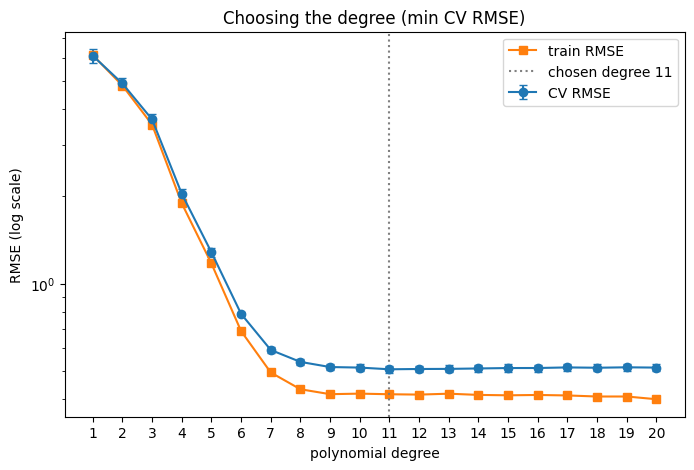

In [13]:
df = pd.read_csv("output_var2/degree_summary.csv"); print(df)

best = df.cv_rmse.idxmin()   # always choose the model with lowest validation (CV) RMSE
chosen = int(df.deg[best])
print(f"lowest CV RMSE: degree {chosen} ({df.cv_rmse[best]:.4f}) — selected as final model")

plt.figure(figsize=(8, 5))
plt.errorbar(df.deg, df.cv_rmse, yerr=df.cv_se, marker="o", capsize=3, label="CV RMSE")
plt.plot(df.deg, df.train_rmse, marker="s", label="train RMSE")
plt.axvline(chosen, color="gray", ls=":", label=f"chosen degree {chosen}")
plt.yscale("log"); plt.xticks(range(1, int(df.deg.max()) + 1))
plt.xlabel("polynomial degree"); plt.ylabel("RMSE (log scale)"); plt.legend(); plt.title("Choosing the degree (min CV RMSE)")
plt.savefig("output_var2/degree_comparison.png", dpi=110); plt.show()


final model: degree 11, λ1=0.0, λ2=0.1
out-of-fold RMSE: 0.5015 | R²: 0.9949
test pred range: -28.58 38.81 | train y range: -29.510000228881836 39.33000183105469


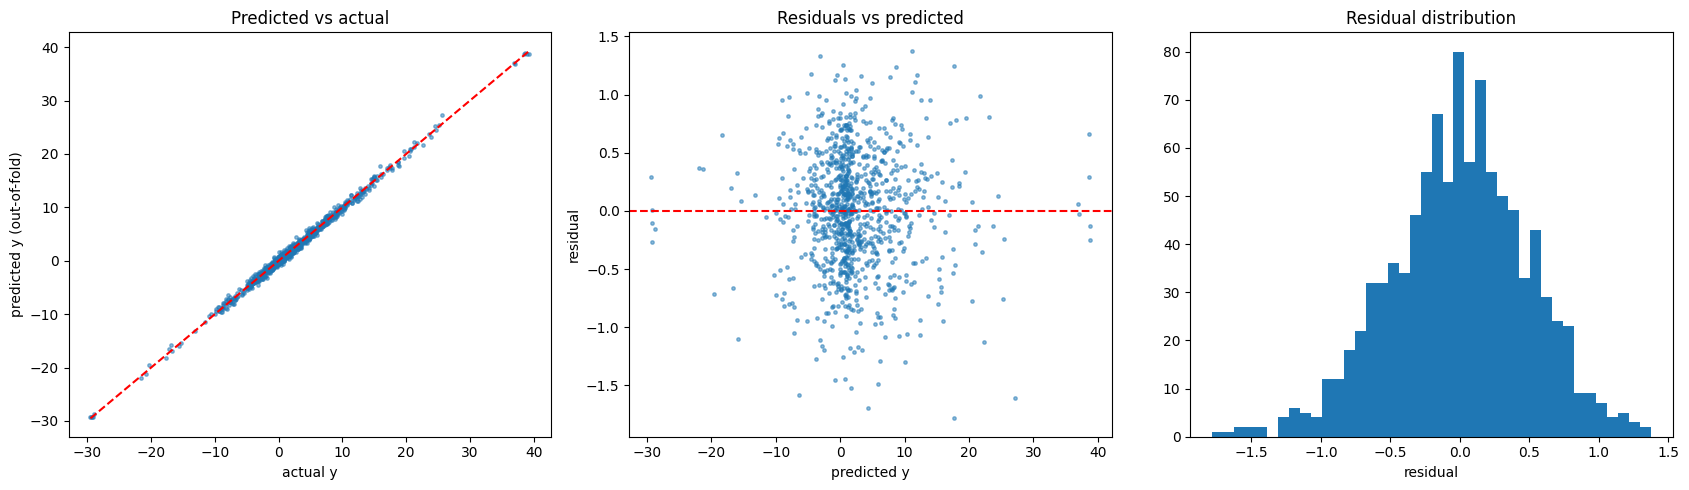

0 clipped coords:  414 rows, RMSE 0.486
1 clipped coords:  424 rows, RMSE 0.499
2 clipped coords:  143 rows, RMSE 0.534
3 clipped coords:   19 rows, RMSE 0.619
x1 x2                               2.486
x1 x1 x1 x1 x2 x3 x3 x3 x3 x3 x3    2.422
x2 x2 x2 x2 x2 x2 x2 x2 x2 x3      -2.340
x2 x2 x3 x3 x3                      2.284
x2 x2 x2 x2 x2 x2                   2.225
x1 x1 x1 x3                         1.930
x2 x2 x2 x2                         1.857
x1 x1 x1 x2 x2 x2 x2 x2 x3 x3       1.848
x1 x1 x1 x1 x1 x2 x2 x2 x3 x3       1.825
x1 x1 x1 x1 x3 x3 x3 x3             1.823
x1 x2 x2 x2 x2 x2 x2 x2 x2 x2 x3   -1.716
x1 x1 x1 x2 x2 x3                   1.677
x1 x1 x1 x1 x1 x1 x3 x3 x3 x3       1.656
x2 x2 x2 x3 x3                      1.636
x2 x2 x3 x3 x3 x3 x3                1.634
dtype: float32


In [14]:
row = df.loc[df.deg == chosen].iloc[0]
DEG, LAM1, LAM2 = int(row.deg), float(row.lam1), float(row.lam2)
print(f"final model: degree {DEG}, λ1={LAM1}, λ2={LAM2}")

Phi = poly_features(X, DEG)
Phi_test = poly_features(X_test, DEG)
Y = y
n, K = len(Phi), 10

# ---- out-of-fold predictions (each row predicted by a model that never saw it) ----
folds = torch.randperm(n, generator=torch.Generator(device="cpu").manual_seed(0)).chunk(K)
oof = torch.zeros(n, dtype=DTYPE, device=DEVICE)
for k in range(K):
    va = folds[k].to(DEVICE)
    tr = torch.cat([folds[j] for j in range(K) if j != k]).to(DEVICE)
    ones = torch.ones(len(tr), 1, dtype=DTYPE, device=DEVICE)
    sigma = torch.linalg.matrix_norm(torch.cat([Phi[tr], ones], 1), 2)
    w_k, b_k, _ = fit_enet(Phi[tr], Y[tr], LAM1, LAM2, sigma, 800)
    oof[va] = Phi[va] @ w_k + b_k
res = (Y - oof).detach().cpu().numpy()
y_cpu = y.detach().cpu().numpy()
print(f"out-of-fold RMSE: {np.sqrt((res**2).mean()):.4f} | R²: {1 - (res**2).sum() / ((y_cpu - y_cpu.mean())**2).sum():.4f}")

# ---- final model and test predictions ----
r = torch.load(f"output_var2/deg{DEG}/results.pt", map_location="cpu", weights_only=False)
w, b = r["w"], r["b"]
# w/b are on CPU; predict on GPU then move back
w_d = w.to(device=DEVICE, dtype=DTYPE)
b_d = b.to(device=DEVICE, dtype=DTYPE)
test_pred = (Phi_test @ w_d + b_d).detach().cpu().numpy()
pd.DataFrame({"y_pred": test_pred}).to_csv("output_var2/test_predictions_final.csv", index=False)
print("test pred range:", test_pred.min().round(2), test_pred.max().round(2),
      "| train y range:", float(y_cpu.min().round(2)), float(y_cpu.max().round(2)))

# ---- diagnostic plots ----
oof_np = oof.detach().cpu().numpy()
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].scatter(y_cpu, oof_np, s=6, alpha=0.5); ax[0].plot([y_cpu.min(), y_cpu.max()], [y_cpu.min(), y_cpu.max()], "r--")
ax[0].set(xlabel="actual y", ylabel="predicted y (out-of-fold)", title="Predicted vs actual")
ax[1].scatter(oof_np, res, s=6, alpha=0.5); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="predicted y", ylabel="residual", title="Residuals vs predicted")
ax[2].hist(res, bins=40); ax[2].set(xlabel="residual", title="Residual distribution")
plt.tight_layout(); plt.savefig("output_var2/diagnostics.png", dpi=110); plt.show()

# ---- error vs number of coordinates sitting exactly on the +-1 edge ----
n_clip = (np.abs(X_np) == 1).sum(1)
for c in range(4):
    m = n_clip == c
    if m.sum() > 10:
        print(f"{c} clipped coords: {m.sum():4d} rows, RMSE {np.sqrt((res[m]**2).mean()):.3f}")

# ---- strongest terms ----
def term_names(deg, nv=3):
    if BASIS == "monomial":
        return [" ".join(f"x{i+1}" for i in c) for d in range(1, deg + 1)
                for c in itertools.combinations_with_replacement(range(nv), d)]
    return [" ".join(f"P{e[i]}(x{i+1})" for i in range(nv) if e[i] > 0)
            for e in itertools.product(range(deg + 1), repeat=nv) if 0 < sum(e) <= deg]
top = pd.Series(w.numpy() if hasattr(w, "numpy") else np.asarray(w), index=term_names(DEG))
top = top[top != 0]
print(top.reindex(top.abs().sort_values(ascending=False).index).head(15).round(3))


In [15]:
! zip -r output_var2.zip output_var2/

updating: output_var2/ (stored 0%)
updating: output_var2/degree_summary.csv (deflated 51%)
updating: output_var2/deg11/ (stored 0%)
updating: output_var2/deg11/cv_heatmap.png (deflated 18%)
updating: output_var2/deg11/train_val_curves.png (deflated 16%)
updating: output_var2/deg11/test_predictions.csv (deflated 50%)
updating: output_var2/deg11/results.pt (deflated 16%)
updating: output_var2/deg1/ (stored 0%)
updating: output_var2/deg9/ (stored 0%)
updating: output_var2/deg9/cv_heatmap.png (deflated 18%)
updating: output_var2/deg9/train_val_curves.png (deflated 16%)
updating: output_var2/deg9/test_predictions.csv (deflated 50%)
updating: output_var2/deg9/results.pt (deflated 16%)
updating: output_var2/degree_comparison.png (deflated 8%)
updating: output_var2/test_predictions_final.csv (deflated 50%)
updating: output_var2/deg12/ (stored 0%)
updating: output_var2/deg12/cv_heatmap.png (deflated 18%)
updating: output_var2/deg12/train_val_curves.png (deflated 16%)
updating: output_var2/deg12